# **Amostragem e divisão de dados**
<font size=3>
    
Em Aprendizado de Máquina, nosso objetivo final não é criar um modelo que **apenas memorize** os dados de treino, mas sim um que consiga **generalizar** e fazer previsões precisas sobre **dados novos** e nunca vistos. A **amostragem e a divisão de dados** são o pilar para alcançar esse objetivo. Através de uma avaliação confiável, essas técnicas nos permitem simular como nosso modelo se comportará no mundo real, estimando seu desempenho em dados que não foram utilizados no treinamento. Nesta aula, exploraremos as principais estratégias para dividir nossos dados, entendendo as vantagens e limitações de cada uma.


## **1. _Holdout_ e Amostragem Aleatória:**
<font size=3>
    
**_Holdout_** é a forma mais simples de divisão de dados, onde os dados são divididos em dois (ou três) subconjuntos:
* **Treinamento**: usado para ajustar o modelo ($\sim 60\%-80\%$);
* **Teste**: usado para avaliar o desempenho ($\sim 10\%-30\%$);
* **Validação**: usado para ajuste de hiperparâmetros ($\sim 20\%-30\%$).

<font size=3>

O que acontece se as classes do nosso conjunto de dados **não estiverem distribuídas de forma igual**? Esse cenário, conhecido como **desbalanceamento de classes**, é extremamente comum em problemas do mundo real, como detecção de fraudes ou diagnósticos médicos.

Uma divisão **puramente aleatória** pode criar uma situação enganosa: por puro acaso, nosso conjunto de teste poderia acabar com **poucos ou até nenhum** exemplo da classe minoritária. Se isso acontecer, um modelo que simplesmente **"chuta"** a classe majoritária para todas as previsões alcançaria uma acurácia alta, mas seria completamente inútil na prática.

### **1.1 Amostragem estratificada:**
<font size=3>
    
Para resolver esse problema, utilizamos a **amostragem estratificada**. A ideia é simples: ao invés de sortear os dados de forma completamente aleatória, **a divisão é feita de forma a manter a proporção original das classes** em cada um dos subconjuntos (treino, validação e teste).


In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
# simulando dados desbalanceados (90% classe 0, 10% classe 1)
X, y = make_classification(n_samples=100, n_classes=2, weights=[0.9, 0.1], random_state=42)
y

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [3]:
np.unique(y, return_counts=True)

(array([0, 1]), array([90, 10]))

In [4]:
# divisão estratificada entre treinamento e teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
y_train, y_test

(array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0]),
 array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1]))

In [5]:
# verificando as proporções:
print(f"Proporção da classe 1 no treino: {y_train.mean():.2f}")
print(f"Proporção da classe 1 no teste: {y_test.mean():.2f}\n")

Proporção da classe 1 no treino: 0.10
Proporção da classe 1 no teste: 0.10



### **1.2 Afinação de hiperparâmetros com dados de validação:**
<font size=3>

A melhor forma de se **afinar hiperparâmetros** de um modelo — como o valor $k$ do modelo k-NN — **sem viés de dados de teste**, é utilizar os **dados de validação**. A ideia é treinar várias versões do modelo nos dados de treino e avaliá-las no conjunto de validação. A versão com melhor desempenho é a escolhida. O conjunto de teste final permanece intocado durante esse processo, sendo usado apenas uma vez para garantir uma avaliação honesta e imparcial do modelo.

> **Analogia:** O professor preparou 100 questões para uma unidade da disciplina:
> - **(treinamento):** 70 questões servirão para listas de exercícios;
> - **(validação):** 20 questões serão usadas como avaliação pré-prova — para que os alunos saibam onde melhorar nos estudos;
> - **(teste):** 10 questões farão parte da prova da unidade.


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [7]:
# Exemplo de divisão dos dados em Treinamento, Validação e Teste:

# simulando dados para classificação:
X, y = make_classification(n_samples=1000, n_features=8, n_classes=2, weights=[0.7, 0.3], random_state=42, flip_y=0.1)

# dividindo os dados entre treino(60%)  e de desenvolvimento (40%):
X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.4, stratify=y)

# dividindo os dados de desenvolvimento entre validação (20%) e teste (20%):
X_val, X_test, y_val, y_test = train_test_split(X_dev, y_dev, test_size=0.5, stratify=y_dev)

print(f"X-train:{X_train.shape}, X-val:{X_val.shape}, X-test:{X_test.shape}")
print(f"y-train:{y_train.shape}, y-val:{y_val.shape}, y-test:{y_test.shape}")

X-train:(600, 8), X-val:(200, 8), X-test:(200, 8)
y-train:(600,), y-val:(200,), y-test:(200,)


In [8]:
# verificando as proporções:
print(f"Proporção da classe 1 no treino: {y_train.mean():.2f}")
print(f"Proporção da classe 1 na validation: {y_val.mean():.2f}")
print(f"Proporção da classe 1 no teste: {y_test.mean():.2f}")

Proporção da classe 1 no treino: 0.33
Proporção da classe 1 na validation: 0.33
Proporção da classe 1 no teste: 0.33


In [9]:
# ajustar k usando o conjunto de validação:
scores = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred_val = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred_val)

    scores.append(acc)

# escolher o melhor k:
best_k = np.argmax(scores) + 1 # se soma "+1" já o que 1ª índice é 0
print(f"Melhor k (validação): {best_k}")

Melhor k (validação): 11


In [10]:
# avaliar no conjunto de teste:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(np.concatenate([X_train, X_val]),
                np.concatenate([y_train, y_val]))

y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia no conjunto de teste: {acc:.2f}")

Acurácia no conjunto de teste: 0.81


<font size=3>
    
A **vantagem** do **_holdout_ estratificado** é unir a velocidade do método a uma avaliação mais justa em dados desbalanceados, pois preserva a proporção das classes. Sua principal **desvantagem** é que a performance ainda depende de uma única divisão de dados, o que pode gerar uma estimativa com alta variância, sendo menos robusta que a validação cruzada.

## **2. Validação Cruzada K-fold (_Cross-Validation_):**
<font size=3>
    
A **validação cruzada** é uma técnica mais robusta e estatisticamente confiável para estimar o **desempenho** de modelos — especialmente para **conjuntos de dados pequenos** ($\;\sim$ 1000 amostras).

<font size=3>

 * O conjunto de dados é dividido em **$k$ partes (_folds_)**.
 * O modelo é treinado em $k-1$ partes e testado na parte restante.
 * O processo se repete **$k$ vezes**, com cada _fold_ servindo como validação uma vez.
 * O desempenho final é a **média dos $k$ testes**.
   

<font size=3><center>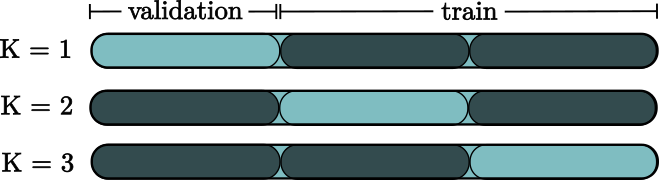</center>

<font size=3>
    
No **scikit-learn**, existem duas maneiras (que podem se combinar) de se realizar a validação **k-Fold**:
1. A **forma explícita** usando o objeto [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) — indicado para um melhor controle do processo interativo e divisão dos dados;

2. A **forma implícita** com a função [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) — indicado para implementações simples e enxutas.

Na seguintes subseções iremos demonstrar o uso de ambas as formas, mas observe que a escolha da implementação é **independente** se iremos afinar ou não os hiperparâmetros de um modelo.

### **2.1 _Sem_ afinação de hiperparâmetros _ou_ dataset $\sim 100$ amostras:**
<font size=3>

Nesta seção, iremos considerar o caso em que **não** precisaremos **afinar hiperparâmetros** do modelo, **ou** caso nosso *dataset* seja **muito pequeno** (da ordem de $10^2$ amostras) — onde, mesmo no caso que haja necessidade de afinar hiperparâmetros, dividir o *dataset* irá prejudicar o treinamento ou a avaliação do modelo.

A seguir, vamos usar a forma explícita, declarando o objeto `KFold`, onde definimos o números de *folds* e se queremos embaralhar os dados ou não.

In [11]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [12]:
# simulando dados:
X, y = make_regression(n_samples=180, n_features=5, noise=0.5, random_state=42)

# definindo o objeto KFold para a separação do dados:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

<font size=3>

O objeto `kf` irá retornar os índices de dados de treino e validação/teste, com base no *array* `X`.

> Como nosso *dataset* é pequeno, com apenas 180 amostras, faremos o tratamento **inverso** do modelo: primeiro o avaliamos, depois faremos um treinamento final.

In [14]:
# lista para armazenar o erro de cada fold:
scores = []

# o método kf.split() gera os índices de treino e teste para cada um dos folds:
for fold, (train_indices, test_indices) in enumerate(kf.split(X)):

    # definindo o modelo:
    model = LinearRegression()

    # separando os dados de treino e teste:
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # fitando o modelo:
    model.fit(X_train, y_train)

    # previsão com dados de teste:
    y_pred = model.predict(X_test)

    # avaliando o treinamento no fold:
    mse = mean_squared_error(y_test, y_pred)
    scores.append(mse)

    print(f"Fold {fold+1}: X-train = {X_train.shape}, X-test = {X_test.shape}, MSE = {mse:.3f}")

print(f"\nMSE = {np.mean(scores):.2f} +/- {np.std(scores):.2f}\n")

Fold 1: X-train = (120, 5), X-test = (60, 5), MSE = 0.219
Fold 2: X-train = (120, 5), X-test = (60, 5), MSE = 0.224
Fold 3: X-train = (120, 5), X-test = (60, 5), MSE = 0.248

MSE = 0.23 +/- 0.01



<font size=3>

    
O resultado acima mostra a média e desvio padrão da performance do modelo neste *dataset*. Então, **qual modelo iremos utilizar como "final"?**
- Iremos retreinar o modelo com **todo o _dataset_** (já que temos **poucos dados**) para obtermos o modelo final;
- Avaliação *k-fold* (acima) servirá de **limite superior** da performance, pois os modelos avaliados durante a validação cruzada foram treinados com apenas 2/3 dos dados. O modelo final, ao aprender com 100% dos dados, tem o potencial de alcançar um desempenho ligeiramente melhor, resultando em um MSE real possivelmente menor que o estimado.


In [15]:
# reiniciando o modelo:
final_model = LinearRegression()

# fitando o modelo com todo o dataset:
final_model.fit(X, y)

LinearRegression()

<font size=3>
    
O mesmo resultado de avaliação, usando o objeto `KFold`, pode ser obtido pelas linhas:

<font size=2.5>
    
>```python
>model = LinearRegression()
>scores = cross_val_score(model, X, y, cv=3, scoring='neg_mean_squared_error')
>```

<font size=3>
<br>
    
Ou ainda, caso queiramos usar o objeto `kf`, a fim de assegurar o controle sobre o embaralhamento e divisão de dados, podemos definí-lo à variável `cv` da função `cross_val_score`:

<font size=2.5>
    
>```python
>kf = KFold(n_splits=3, shuffle=True, random_state=42)
>scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
> ```

<font size=3>
<br>
    
A função `cross_val_score`, por convenção, sempre escolherá o **maior valor** da métrica definida em `scoring`. Assim, métricas como MSE, cujos melhores valores são próximos de zero, serão multiplicadas por $-1$ para que o "maior valor" seja escolhido.

### **2.2 _Com_ afinação de hiperparâmetros _e_ dataset $\sim 1000$ amostras:**
<font size=3>

Nesta seção, iremos considerar o caso que precisaremos **afinar hiperparâmetros** do modelo **e**
nosso *dataset* apresenta um tamanho (da ordem de $10^3$ amostras) para se fazer as divisões entre treinamento, validação e teste.

> Mas se eu tenho um *dataset* com $\sim 100$ amostras e **preciso** afinar hiperparâmetros, o que faço?\
> Use o procedimento da seção anterior!


In [16]:
from sklearn.model_selection import cross_val_score

In [17]:
# simulando dados:
X, y = make_classification(n_samples=1600, n_features=5, random_state=42)

# dividindo os dados entre Dev (k-Fold) e Test (avaliação final):
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.3)


In [18]:
scores = []

for k in range(1, 16):

    model = KNeighborsClassifier(n_neighbors=k)

    scores_k = cross_val_score(model, X_dev, y_dev, cv=3, scoring='accuracy')

    scores.append(scores_k.mean())

    print(f"k = {k}, Acurácia = {scores_k}, Média = {scores_k.mean():.3f}")

print(f"\nAcc = {np.mean(scores):.2f} +/- {np.std(scores):.2f}\n")

k = 1, Acurácia = [0.91176471 0.95710456 0.94906166], Média = 0.939
k = 2, Acurácia = [0.9144385  0.95174263 0.94101877], Média = 0.936
k = 3, Acurácia = [0.92780749 0.95710456 0.9463807 ], Média = 0.944
k = 4, Acurácia = [0.93048128 0.94906166 0.94369973], Média = 0.941
k = 5, Acurácia = [0.92513369 0.95174263 0.94101877], Média = 0.939
k = 6, Acurácia = [0.93315508 0.94906166 0.93565684], Média = 0.939
k = 7, Acurácia = [0.92513369 0.94906166 0.9383378 ], Média = 0.938
k = 8, Acurácia = [0.93315508 0.93297587 0.92761394], Média = 0.931
k = 9, Acurácia = [0.93048128 0.93297587 0.93565684], Média = 0.933
k = 10, Acurácia = [0.93048128 0.92493298 0.93297587], Média = 0.929
k = 11, Acurácia = [0.92513369 0.93029491 0.93297587], Média = 0.929
k = 12, Acurácia = [0.92513369 0.93029491 0.93297587], Média = 0.929
k = 13, Acurácia = [0.9197861  0.92493298 0.92493298], Média = 0.923
k = 14, Acurácia = [0.92513369 0.92493298 0.92225201], Média = 0.924
k = 15, Acurácia = [0.92513369 0.92225201 0

In [19]:
# melhor valor de k segundo a avaliação cruzada k-fold:
best_k = np.argmax(scores) + 1

print("Melhor valor de k:", best_k)

Melhor valor de k: 3


In [20]:
# treinamento final com o melhor valor do hiperparâmetro:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_dev, y_dev)

# predição e avaliação do final:
y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Acurárica = {acc:.3f}")

Acurárica = 0.952


### **2.3 Conjunto de dados desbalanceados:**
<font size=3>

Em tarefas de classificação com *dataset* **desbalanceados**, a função `cross_val_score` já realiza a **amostragem estratificada _automaticamente_**. Caso deseje realizar a estratificação utilizando uma **abordagem explícita**, utilize o objeto [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html) como segue abaixo.

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

In [22]:
X, y = make_classification(n_samples=400, n_classes=2, weights=[0.70, 0.30], random_state=42)

np.unique(y, return_counts=True)

(array([0, 1]), array([277, 123]))

In [23]:
# definindo o objeto de separação estratificada dos índices dos dados:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# lista para armazenar o erro de cada fold:
scores = []

# o método skf.split() gera os índices de treino e teste estratificado:
for fold, (train_indices, test_indices) in enumerate(skf.split(X, y)):

    # definindo o modelo:
    model = LogisticRegression()

    # separando os dados de treino e teste:
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # fitando o modelo:
    model.fit(X_train, y_train)

    # previsão com dados de teste:
    y_pred = model.predict(X_test)

    # avaliando o treinamento no fold:
    scores.append(accuracy_score(y_test, y_pred))

    print(f"Fold {fold+1}: X-train = {X_train.shape}, X-test = {X_test.shape}, MSE = {mse:.2f}")

print(f"\nAcc = {np.mean(scores):.2f} +/- {np.std(scores):.2f}\n")


Fold 1: X-train = (266, 20), X-test = (134, 20), MSE = 0.25
Fold 2: X-train = (267, 20), X-test = (133, 20), MSE = 0.25
Fold 3: X-train = (267, 20), X-test = (133, 20), MSE = 0.25

Acc = 0.92 +/- 0.03



<font size=3>

A principal **vantagem** da **validação cruzada K-fold** é sua robustez: ao treinar e testar o modelo em todas as partes dos dados, ela oferece uma estimativa de desempenho muito mais estável e confiável do que o **_holdout_**, reduzindo o viés de uma única divisão. A principal **desvantagem** é o custo computacional, pois o processo exige que o modelo seja treinado $k$ vezes, tornando-o significativamente mais lento, especialmente com modelos complexos ou grandes conjuntos de dados.


## **3. _Bootstrap_:**
<font size=3>

A técnica de **avaliação de modelo _bootstrap_** é uma abordagem estatística baseada em **reamostragem com reposição**. Semelhante ao método K-fold, ele avalia a **estabilidade e variância de modelos**, especialmente quando temos **poucos dados**.

<font size=3>

- Suponha que você tenha um conjunto de dados com $n$ amostras.

- O método consiste em gerar **B** conjuntos de dados (chamados de *bootstrap samples*) com **$n$ amostras cada**, sorteadas **com reposição** do conjunto original, *i.e.*, **cada elemento do conjunto original pode ser escolhido mais de uma vez**.

- Para cada um desses B conjuntos:

   * Treina-se o modelo no *bootstrap sample*.
   * Avalia-se o desempenho em outro conjunto, chamado **out-of-bag (OOB)**, ou seja, os dados que **não foram escolhidos** naquele bootstrap.

- Após as B iterações, calcula-se a **média** e a **desvio padrão** das performances registradas.

In [24]:
X, y = make_regression(n_samples=180, n_features=5, noise=0.5, random_state=42)

In [27]:
B = 10     # número de interações
n = len(X) # número de amostras

scores = []

for i in range(B):

    # definindo o modelo:
    model = LinearRegression()

    # amostra com reposição:
    indices = np.random.choice(range(n), size=n)
    X_boot = X[indices] # train
    y_boot = y[indices] # train

    # out-of-bag (OOB) - dados não selecionados:
    oob_indices = list(set(range(n)) - set(indices))
    if not oob_indices:
        continue  # pular se não houver OOB

    X_oob = X[oob_indices] # val/test
    y_oob = y[oob_indices] # val/test

    model.fit(X_boot, y_boot)
    y_pred = model.predict(X_oob)

    scores.append(mean_squared_error(y_oob, y_pred))

    print(f"Interação {i+1}: X-bootstrap = {X_boot.shape}, X-oob = {X_oob.shape}, MSE = {mse:.4f}")

print(f"\nMSE = {np.mean(scores):.3f} +/- {np.std(scores):.3f}\n")

Interação 1: X-bootstrap = (180, 5), X-oob = (61, 5), MSE = 0.2482
Interação 2: X-bootstrap = (180, 5), X-oob = (62, 5), MSE = 0.2482
Interação 3: X-bootstrap = (180, 5), X-oob = (62, 5), MSE = 0.2482
Interação 4: X-bootstrap = (180, 5), X-oob = (59, 5), MSE = 0.2482
Interação 5: X-bootstrap = (180, 5), X-oob = (66, 5), MSE = 0.2482
Interação 6: X-bootstrap = (180, 5), X-oob = (65, 5), MSE = 0.2482
Interação 7: X-bootstrap = (180, 5), X-oob = (69, 5), MSE = 0.2482
Interação 8: X-bootstrap = (180, 5), X-oob = (66, 5), MSE = 0.2482
Interação 9: X-bootstrap = (180, 5), X-oob = (68, 5), MSE = 0.2482
Interação 10: X-bootstrap = (180, 5), X-oob = (70, 5), MSE = 0.2482

MSE = 0.245 +/- 0.026



<font size=3>
<br>
    
Em tarefas de **classificação**, caso o *dataset* esteja **desbalanceado**, a **amostrada estratificada** no método *bootstrap* é feita da seguinte forma.

In [28]:
X, y = make_classification(n_samples=400, n_classes=2, weights=[0.70, 0.30], random_state=42)

# separando os índices para cada classe:
indices_classe_0 = np.where(y == 0)[0]
indices_classe_1 = np.where(y == 1)[0]

# contando quantos exemplos temos em cada classe:
n0 = len(indices_classe_0)
n1 = len(indices_classe_1)

In [29]:
B = 10     # número de interações
n = len(X) # número de amostras

scores = []

for i in range(B):

    # definindo o modelo:
    model = LogisticRegression()

    # sortear com reposição dentro de cada classe:
    boot_indices_0 = np.random.choice(indices_classe_0, size=n0, replace=True)
    boot_indices_1 = np.random.choice(indices_classe_1, size=n1, replace=True)

    # juntando os índices para criar a amostra bootstrap estratificada:
    indices = np.concatenate([boot_indices_0, boot_indices_1])

    X_boot = X[indices]
    y_boot = y[indices]

    # out-of-bag (OOB) - dados não selecionados:
    oob_indices = list(set(range(n)) - set(indices))

    if not oob_indices:
        continue

    X_oob = X[oob_indices]
    y_oob = y[oob_indices]

    model.fit(X_boot, y_boot)
    y_pred = model.predict(X_oob)

    acc = accuracy_score(y_oob, y_pred)
    scores.append(acc)

    print(f"Interação {i+1}: X-bootstrap = {X_boot.shape}, X-oob = {X_oob.shape}, Acc = {acc:.2f}")

print(f"\nAcc = {np.mean(scores):.3f} +/- {np.std(scores):.3f}\n")

Interação 1: X-bootstrap = (400, 20), X-oob = (151, 20), Acc = 0.91
Interação 2: X-bootstrap = (400, 20), X-oob = (139, 20), Acc = 0.91
Interação 3: X-bootstrap = (400, 20), X-oob = (136, 20), Acc = 0.92
Interação 4: X-bootstrap = (400, 20), X-oob = (155, 20), Acc = 0.93
Interação 5: X-bootstrap = (400, 20), X-oob = (151, 20), Acc = 0.92
Interação 6: X-bootstrap = (400, 20), X-oob = (150, 20), Acc = 0.89
Interação 7: X-bootstrap = (400, 20), X-oob = (160, 20), Acc = 0.89
Interação 8: X-bootstrap = (400, 20), X-oob = (137, 20), Acc = 0.88
Interação 9: X-bootstrap = (400, 20), X-oob = (141, 20), Acc = 0.91
Interação 10: X-bootstrap = (400, 20), X-oob = (151, 20), Acc = 0.89

Acc = 0.906 +/- 0.014



<font size=3>

A principal **vantagem** do **_boot_** é sua capacidade de estimar a estabilidade e a variância do desempenho de um modelo, sendo muito eficaz em **datasets pequenos** por reutilizar os dados de forma intensiva. Ao gerar uma distribuição de métricas, ele oferece uma visão mais completa da performance do que um único número. Suas **desvantagens** são o maior custo computacional, por treinar múltiplos modelos, e sua complexidade conceitual. Além disso, por fazer amostragem com reposição, a avaliação pode ser sensível a _outliers_, que podem acabar super-representados em algumas amostras.


## **Resumo dos métodos:**
<font size=3>

| Técnica          | Quando usar                                | Vantagens                                   | Desvantagens                             |
| ---------------- | ------------------------------------------ | ------------------------------------------- | ---------------------------------------- |
| **Holdout**          | Modelos rápidos ou conjuntos grandes       | Simples, rápido                             | Avaliação instável em conjuntos pequenos |
| **K-fold Cross-Validation** | Avaliação robusta, tuning de modelo        | Estável, estatisticamente confiável         | Mais caro computacionalmente             |
| **Bootstrap**        | Conjuntos pequenos ou análise de variância | Gera distribuição de erros, reutiliza dados | Mais complexo, pode ser sensível a ruído |

<br>

## __Referências:__
<font size=3>

- **(9.2)**: K. Faceli, _Inteligência artificial: uma abordagem de aprendizado de máquina_. Grupo Gen - LTC, 2011.
  